# Customer Churn Analysis — Python Data Analysis Project

## Project Overview

This project analyzes customer churn data to identify key factors related to customer cancellation behavior.  
The goal is to explore customer characteristics, service usage, contract type, payment method, tenure, and monthly charges to generate business insights that can support customer retention strategies.

## Dataset

The dataset contains customer information from a telecom company, including demographic information, account details, subscribed services, and churn status.

Main columns include:

- Customer ID
- Gender
- Senior Citizen
- Partner
- Dependents
- Tenure
- Phone Service
- Internet Service
- Contract
- Payment Method
- Monthly Charges
- Total Charges
- Churn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\Alireza\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Alireza\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## Load Dataset

In [ ]:
df = pd.read_csv(r"data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [21]:
df.shape

(7043, 21)

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [23]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [24]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Data Cleaning

In [25]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.isnull().sum()
df = df.dropna()
df.duplicated().sum()

0

## Churn Overview KPIs

In [26]:
total_customers = df["customerID"].nunique()
churned_customers = df[df["Churn"] == "Yes"]["customerID"].nunique()
retained_customers = df[df["Churn"] == "No"]["customerID"].nunique()
churn_rate = churned_customers / total_customers * 100

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Retained Customers:", retained_customers)
print("Churn Rate:", round(churn_rate, 2), "%")

Total Customers: 7032
Churned Customers: 1869
Retained Customers: 5163
Churn Rate: 26.58 %


## Churn Distribution

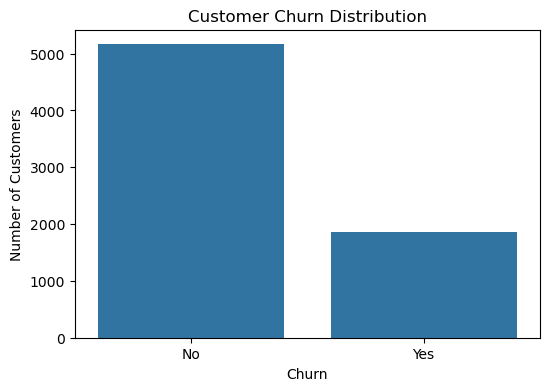

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

## Churn by Contract Type

In [28]:
contract_churn = df.groupby("Contract")["Churn"].value_counts(normalize=True).unstack() * 100
contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


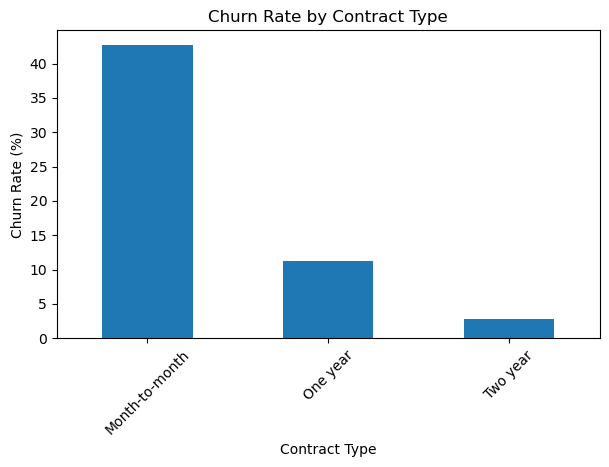

In [29]:
contract_churn["Yes"].sort_values(ascending=False).plot(kind="bar", figsize=(7,4))

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

## Churn by Payment Method

In [30]:
payment_churn = df.groupby("PaymentMethod")["Churn"].value_counts(normalize=True).unstack() * 100
payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


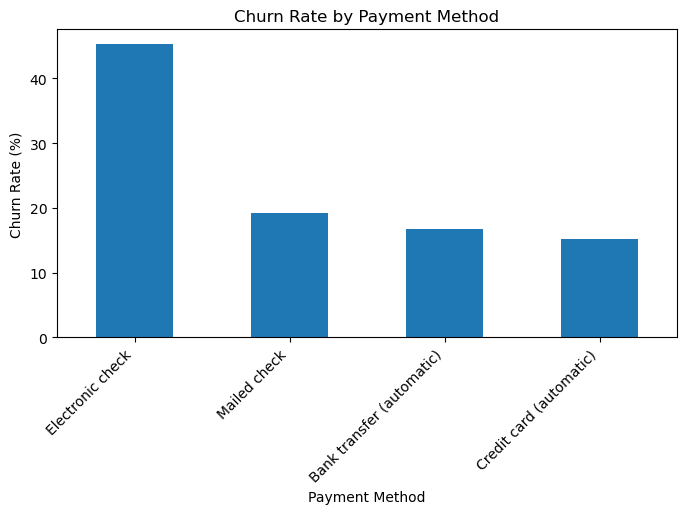

In [31]:
payment_churn["Yes"].sort_values(ascending=False).plot(kind="bar", figsize=(8,4))

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

## Churn by Internet Service

In [32]:
internet_churn = df.groupby("InternetService")["Churn"].value_counts(normalize=True).unstack() * 100
internet_churn

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


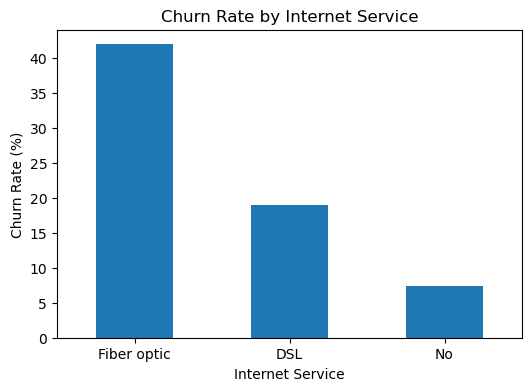

In [33]:
internet_churn["Yes"].sort_values(ascending=False).plot(kind="bar", figsize=(6,4))

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

## Tenure Analysis

In [34]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=["0-12", "13-24", "25-36", "37-48", "49-60", "61-72"]
)

tenure_churn = df.groupby("TenureGroup")["Churn"].value_counts(normalize=True).unstack() * 100
tenure_churn

Churn,No,Yes
TenureGroup,,
0-12,52.321839,47.678161
13-24,71.289062,28.710938
25-36,78.365385,21.634615
37-48,80.971129,19.028871
49-60,85.576923,14.423077
61-72,93.390192,6.609808


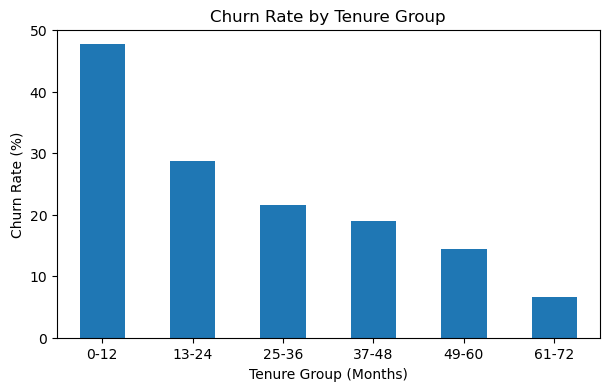

In [35]:
tenure_churn["Yes"].plot(kind="bar", figsize=(7,4))

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group (Months)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

## Monthly Charges vs Churn

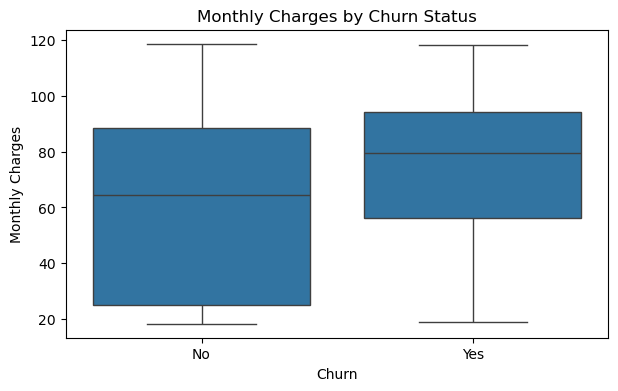

In [36]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

## Total Charges vs Churn

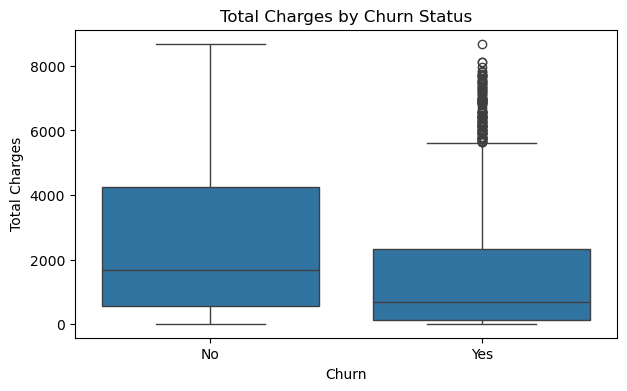

In [37]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Churn", y="TotalCharges")

plt.title("Total Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.show()

## Key Insights

- Customers with month-to-month contracts showed the highest churn rate.
- Customers with shorter tenure were more likely to churn.
- Electronic check users had a higher churn rate compared to other payment methods.
- Customers using fiber optic internet showed higher churn compared to other internet service types.
- Higher monthly charges appeared to be associated with increased churn risk.

## Business Recommendations

- Offer loyalty discounts or contract incentives to month-to-month customers.
- Focus retention campaigns on customers within their first 12 months.
- Investigate customer experience issues among fiber optic users.
- Encourage high-risk customers to switch from electronic check to more stable payment methods.
- Monitor customers with high monthly charges and provide targeted offers or service improvements.